In [ ]:
from google.colab import files
files.upload()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
df = pd.read_csv("nigerian_sme_synthetic_v2.csv")

In [4]:
df.head()

,business_id,business_category,business_age_months,data_confidence_level,history_start_month,monthly_revenue_m1,ussd_transaction_count_m1,mobile_money_frequency_m1,airtime_topup_regularity_m1,card_payment_volume_m1,...,avg_monthly_revenue,revenue_trend,revenue_trend_pct,revenue_volatility,avg_ussd_volume,avg_mobile_money,avg_refund_rate,avg_settlement_days,channel_diversity,cash_flow_risk
0,NG-SME-00001,retail,13,high,11,416992.93,420,257,0.788,32,...,359234.650000,-27371.06,-6.563899,0.128143,407.333333,230.666667,2.336667,1.050000,3,0
1,NG-SME-00002,retail,24,high,8,752132.78,107,64,1.000,27,...,925684.378333,18777.04,2.496503,0.229251,127.833333,80.500000,2.421667,2.700000,3,0
2,NG-SME-00003,food,16,high,5,370563.92,213,122,0.798,5,...,402080.193333,31538.16,8.510833,0.177538,256.500000,101.500000,1.906667,0.866667,3,0
3,NG-SME-00004,services,12,high,12,1046116.10,400,123,0.354,39,...,846957.830000,-331587.86,-31.697012,0.160412,311.833333,96.333333,3.420000,1.866667,3,1
4,NG-SME-00005,retail,39,high,10,751553.85,157,204,0.950,23,...,839084.178333,57430.60,7.641571,0.185713,192.666667,192.833333,2.398333,1.950000,3,0


In [5]:
df.describe()

,business_age_months,history_start_month,monthly_revenue_m1,ussd_transaction_count_m1,mobile_money_frequency_m1,airtime_topup_regularity_m1,card_payment_volume_m1,settlement_consistency_m1,refund_rate_m1,monthly_revenue_m2,...,avg_monthly_revenue,revenue_trend,revenue_trend_pct,revenue_volatility,avg_ussd_volume,avg_mobile_money,avg_refund_rate,avg_settlement_days,channel_diversity,cash_flow_risk
count,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,1.000000e+04,...,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000
mean,44.265900,6.476500,5.768001e+05,252.372000,153.091000,0.670031,21.34900,1.621580,2.303075,5.770135e+05,...,5.773606e+05,600.293345,2.651864,0.162659,252.558183,153.505600,2.303320,1.629762,3.0,0.254000
std,38.450129,3.438521,2.687287e+05,109.110625,71.223578,0.162327,13.08612,0.862551,1.004650,2.651656e+05,...,2.486016e+05,136016.124332,23.230828,0.044241,99.416125,65.541230,0.699687,0.746570,0.0,0.435319
min,3.000000,1.000000,1.163922e+05,49.000000,24.000000,0.072000,0.00000,0.500000,0.000000,1.168728e+05,...,1.456011e+05,-671261.540000,-48.839904,0.022281,75.666667,35.166667,0.371667,0.533333,3.0,0.000000
25%,19.000000,3.000000,3.730325e+05,162.000000,95.000000,0.560000,11.00000,0.900000,1.610000,3.727698e+05,...,3.822228e+05,-75031.695000,-14.147504,0.131782,166.500000,97.166667,1.781667,1.016667,3.0,0.000000
50%,33.000000,6.000000,5.291142e+05,244.000000,148.000000,0.688000,20.00000,1.500000,2.310000,5.297197e+05,...,5.397209e+05,-3439.930000,-0.701609,0.161485,249.250000,153.416667,2.323333,1.283333,3.0,0.000000
75%,56.000000,9.000000,7.327827e+05,330.000000,205.000000,0.787000,31.00000,2.200000,3.000000,7.366963e+05,...,7.414673e+05,74534.355000,16.058179,0.192221,337.166667,208.833333,2.810000,2.100000,3.0,1.000000
max,240.000000,12.000000,1.767398e+06,681.000000,401.000000,1.000000,86.00000,4.600000,5.700000,1.854874e+06,...,1.412782e+06,813425.520000,121.015881,0.342694,491.000000,304.166667,4.423333,3.666667,3.0,1.000000


In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
# Time series features — 6 months of revenue for LSTM sequences
rev_cols    = [f'monthly_revenue_m{i}' for i in range(1,7)]
ussd_cols   = [f'ussd_transaction_count_m{i}' for i in range(1,7)]
mm_cols     = [f'mobile_money_frequency_m{i}' for i in range(1,7)]
refund_cols = [f'refund_rate_m{i}' for i in range(1,7)]
settle_cols = [f'settlement_consistency_m{i}' for i in range(1,7)]

In [8]:
 #Static features — business profile
static_cols = [
    'business_age_months', 'avg_monthly_revenue',
    'revenue_trend_pct', 'revenue_volatility',
    'avg_ussd_volume', 'avg_mobile_money',
    'avg_refund_rate', 'avg_settlement_days',
    'channel_diversity'
]

target = 'cash_flow_risk'

In [9]:
# Shape: (10000, 6, 5) — 6 months, 5 features per month
sequence_features = []
for i in range(1, 7):
    month_data = df[[
        f'monthly_revenue_m{i}',
        f'ussd_transaction_count_m{i}',
        f'mobile_money_frequency_m{i}',
        f'refund_rate_m{i}',
        f'settlement_consistency_m{i}',
    ]].values
    sequence_features.append(month_data)

In [10]:
X_seq = np.stack(sequence_features, axis=1)
X_static = df[static_cols].values
y = df[target].values


In [11]:
print(f"Sequence input shape: {X_seq.shape}")
print(f"Static input shape:   {X_static.shape}")
print(f"Target shape:         {y.shape}")
print(f"Risk rate:            {y.mean():.1%}")


Sequence input shape: (10000, 6, 5)
Static input shape:   (10000, 9)
Target shape:         (10000,)
Risk rate:            25.4%


In [12]:
# Scale sequence features
n_samples, n_steps, n_features = X_seq.shape
X_seq_flat = X_seq.reshape(n_samples, -1)
seq_scaler = StandardScaler()
X_seq_scaled = seq_scaler.fit_transform(X_seq_flat).reshape(n_samples, n_steps, n_features)

# Scale static features
static_scaler = StandardScaler()
X_static_scaled = static_scaler.fit_transform(X_static)

In [13]:
idx = np.arange(n_samples)
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

In [14]:
X_seq_train, X_seq_test     = X_seq_scaled[idx_train], X_seq_scaled[idx_test]
X_static_train, X_static_test = X_static_scaled[idx_train], X_static_scaled[idx_test]
y_train, y_test               = y[idx_train], y[idx_test]

print(f"\nTrain: {X_seq_train.shape} | Test: {X_seq_test.shape}")
print(f"Train risk rate: {y_train.mean():.1%}")
print(f"Test risk rate:  {y_test.mean():.1%}")


Train: (8000, 6, 5) | Test: (2000, 6, 5)
Train risk rate: 25.4%
Test risk rate:  25.4%


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization,
    Concatenate, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.19.0


In [16]:
# Input 1 — time series (6 months x 5 features)
seq_input = Input(shape=(6, 5), name='sequence_input')
x = Bidirectional(LSTM(64, return_sequences=True))(seq_input)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)

# Input 2 — static business features
static_input = Input(shape=(X_static_train.shape[1],), name='static_input')
s = Dense(32, activation='relu')(static_input)
s = BatchNormalization()(s)
s = Dropout(0.2)(s)
s = Dense(16, activation='relu')(s)

# Merge both streams
combined = Concatenate()([x, s])
combined = Dense(32, activation='relu')(combined)
combined = Dropout(0.2)(combined)
combined = Dense(16, activation='relu')(combined)
output = Dense(1, activation='sigmoid', name='output')(combined)

model = Model(inputs=[seq_input, static_input], outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC', 'accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 6, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 128)    │     35,840 │ sequence_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6, 128)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        320 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,225 (321.19 KB)

 Trainable params: 82,161 (320.94 KB)

 Non-trainable params: 64 (256.00 B)

In [17]:
# callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=7,
        mode='max',
        verbose=1,
        min_lr=1e-6
    )
]

# Class weight for 75/25 imbalance
class_weight = {0: 1.0, 1: 3.0}


#train model

In [18]:
history = model.fit(
    [X_seq_train, X_static_train],
    y_train,
    validation_data=([X_seq_test, X_static_test], y_test),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Evaluate
y_prob = model.predict([X_seq_test, X_static_test]).flatten()
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
print(f"\n{'='*40}")
print(f"  LendraAI LSTM AUC-ROC: {auc:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Risk','At Risk'])}")


plt.show()

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - AUC: 0.7828 - accuracy: 0.6908 - loss: 0.8438 - val_AUC: 0.9163 - val_accuracy: 0.8330 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 2/100
 13/125 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - AUC: 0.8925 - accuracy: 0.7958 - loss: 0.6197

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - AUC: 0.9284 - accuracy: 0.8356 - loss: 0.5077 - val_AUC: 0.9704 - val_accuracy: 0.9030 - val_loss: 0.2220 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - AUC: 0.9582 - accuracy: 0.8795 - loss: 0.3860 - val_AUC: 0.9825 - val_accuracy: 0.9165 - val_loss: 0.1902 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - AUC: 0.9742 - accuracy: 0.9085 - loss: 0.3018 - val_AUC: 0.9885 - val_accuracy: 0.9470 - val_loss: 0.1395 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - AUC: 0.9811 - accuracy: 0.9225 - loss: 0.2572 - val_AUC: 0.9927 - val_accuracy: 0.9590 - val_loss: 0.1017 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - AUC: 0.9859 - accuracy: 0.9342 - loss: 0.2200 - val_AUC: 0.9917 - val_accuracy: 0.9350 - val_loss: 0.1294 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - AUC: 0.9873 - accuracy: 0.

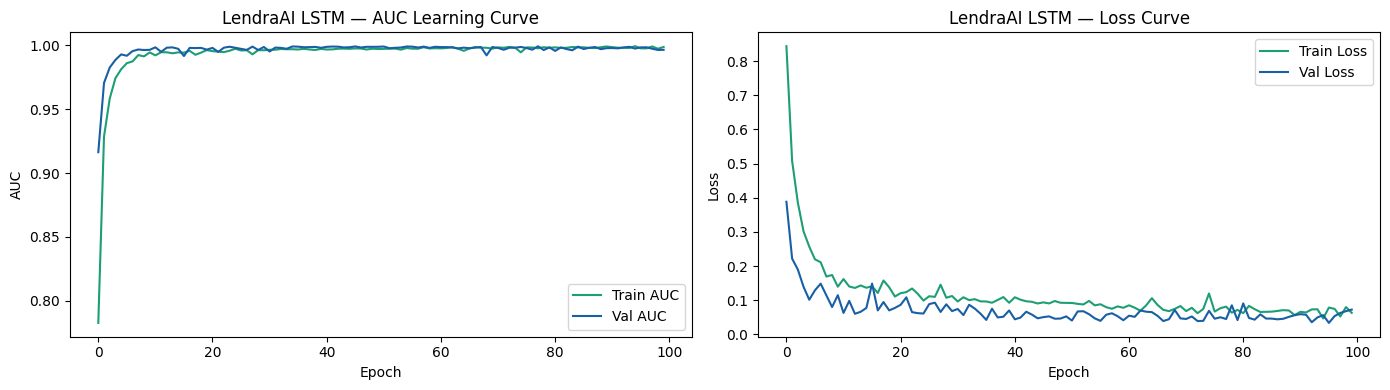


Model saved to ml_forecasting/models/lendraai_lstm_model.h5
Scalers saved


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['AUC'], label='Train AUC', color='#1D9E75')
axes[0].plot(history.history['val_AUC'], label='Val AUC', color='#185FA5')
axes[0].set_title('LendraAI LSTM — AUC Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', color='#1D9E75')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='#185FA5')
axes[1].set_title('LendraAI LSTM — Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_learning_curve.png', dpi=150)
plt.show()

#Save model + scalers
import os, joblib

os.makedirs('ml_forecasting/models', exist_ok=True)
model.save('ml_forecasting/models/lendraai_lstm_model.h5')
joblib.dump(seq_scaler, 'ml_forecasting/models/seq_scaler.pkl')
joblib.dump(static_scaler, 'ml_forecasting/models/static_scaler.pkl')
joblib.dump(static_cols, 'ml_forecasting/models/static_cols.pkl')
print("\nModel saved to ml_forecasting/models/lendraai_lstm_model.h5")
print("Scalers saved")

In [22]:
import shutil
from google.colab import files

# Zip the models directory
shutil.make_archive('lendraai_forecasting_models', 'zip', 'ml_forecasting/models')

# Download the zip file
files.download('lendraai_forecasting_models.zip')

print('Preparing download for lendraai_forecasting_models.zip...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Preparing download for lendraai_forecasting_models.zip...
